In [31]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import MultiPoint


# NWT Databases

## OROGO

In [32]:
# OROGO database
OROGO = pd.read_csv('source_data/wells/NWT/orogo-well-status-updated-2026-04-10.csv').drop(columns=['NAD 27 Lat','NAD 27 Long','Unnamed: 16','Unnamed: 17']).dropna(how='all')
OROGO = gpd.GeoDataFrame(data=OROGO,geometry=gpd.points_from_xy(x=OROGO['NAD_83_LongDD'],y=OROGO['NAD_83_LatDD']),crs='NAD1983')
OROGO['Name'] = OROGO['Well Name'].str.upper()
OROGO = OROGO.set_index('Name',drop=False)
OROGO = OROGO.drop(columns='geometry')
OROGO[['y','x']] = OROGO[['NAD_83_LatDD', 'NAD_83_LongDD']]
OROGO['DS_UID'] = [f'OROGO-{i}' for i in range(0,len(OROGO))]
OROGO['First SPUD year'] = pd.to_datetime(OROGO['First SPUD year'],format='%Y')
print(len(OROGO))
print(OROGO.columns)

685
Index(['Well ID', 'Well Name', 'Last Operator', 'Current or Last Owner',
       'Well Status', 'Classification', 'First SPUD year',
       'Latest SPUD or Start Date', 'Latest Rig Release or End Date',
       'Land Title', 'Region', 'NAD_83_LatDD', 'NAD_83_LongDD', 'UWI', 'Name',
       'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2009-03

In [33]:
NTGS_2009_03 = [r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites.shp',r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites_Peripheral.shp']
NTGS_2009_03 = pd.concat([gpd.read_file(fn).set_index('UWI') for fn in NTGS_2009_03]).to_crs('NAD1983')
NTGS_2009_03['Name'] = NTGS_2009_03['WELL_NAME'].str.upper()
NTGS_2009_03['NAD_83_LatDD'] = NTGS_2009_03.geometry.y
NTGS_2009_03['NAD_83_LongDD'] = NTGS_2009_03.geometry.x
NTGS_2009_03 = NTGS_2009_03.reset_index().set_index('Name',drop=False)
NTGS_2009_03 = NTGS_2009_03.drop(columns='geometry')
NTGS_2009_03[['y','x']] = NTGS_2009_03[['NAD_83_LatDD', 'NAD_83_LongDD']]
NTGS_2009_03['DS_UID'] = [f'NTGS_2009_03-{i}' for i in range(0,len(NTGS_2009_03))]
NTGS_2009_03['SPUD_DATE'] = pd.to_datetime(NTGS_2009_03['SPUD_DATE'])
print(len(NTGS_2009_03))
print(NTGS_2009_03.columns)

549
Index(['UWI', 'WID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'CLASSIFICA',
       'SPUD_DATE', 'RIG_RELEAS', 'LAT', 'LONG', 'DATUM', 'NORTHING',
       'EASTING', 'ZONE', 'SOURCE', 'REFERENCE', 'Name', 'NAD_83_LatDD',
       'NAD_83_LongDD', 'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2019-015

In [34]:
# Report 2019-015
NTGS_2019_015_g = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Gas_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_gas'})
NTGS_2019_015_o = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Oil_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_oil'})

NTGS_2019_015 = pd.concat([
    NTGS_2019_015_g,
    NTGS_2019_015_o.loc[~NTGS_2019_015_o.index.isin(NTGS_2019_015_g.index),NTGS_2019_015_o.columns[NTGS_2019_015_o.columns!='Recoverabl_oil']]
]).to_crs('NAD1983')
NTGS_2019_015 = NTGS_2019_015.join(NTGS_2019_015_o[['Recoverabl_oil']],how='left')
NTGS_2019_015['NAD_83_LatDD'] = NTGS_2019_015.geometry.y
NTGS_2019_015['NAD_83_LongDD'] = NTGS_2019_015.geometry.x
NTGS_2019_015 = NTGS_2019_015.drop(columns='geometry')
NTGS_2019_015[['y','x']] = NTGS_2019_015[['NAD_83_LatDD', 'NAD_83_LongDD']]
NTGS_2019_015['Name'] = NTGS_2019_015['Well_Names'].str.upper()
NTGS_2019_015 = NTGS_2019_015.set_index('Name',drop=False)

NTGS_2019_015 = NTGS_2019_015.sort_index()
NTGS_2019_015 = NTGS_2019_015.loc[~NTGS_2019_015[['UWI']].duplicated(keep='first')]
NTGS_2019_015['DS_UID'] = [f'NTGS_2019_015-{i}' for i in range(0,len(NTGS_2019_015))]
NTGS_2019_015['Discovery'] = pd.to_datetime(NTGS_2019_015['Discovery'],format='%Y')

print(len(NTGS_2019_015))
print(NTGS_2019_015.columns)

167
Index(['NEB_Study', 'NEB_Field', 'WID', 'UWI', 'Well_Names', 'Discovery',
       'Field_Code', 'Pool_Codes', 'Pool_Seq', 'Fluid_Type', 'Initial_Ma',
       'Recoverabl_gas', 'Bot_Hole_L', 'Bot_Hole_1', 'Recoverabl_oil',
       'NAD_83_LatDD', 'NAD_83_LongDD', 'y', 'x', 'Name', 'DS_UID'],
      dtype='str')


# Yukon Data

In [35]:
GeoYukon = gpd.read_file(r'source_data\wells\yukon\Oil_and_Gas_Wells_50k.shp').to_crs('NAD1983').rename(columns={'WELL_UWI':'UWI'})
GeoYukon['Name'] = GeoYukon['WELL_NAME'].str.upper()
GeoYukon = GeoYukon.set_index('Name',drop=False)
GeoYukon['NAD_83_LatDD'] = GeoYukon.geometry.y
GeoYukon['NAD_83_LongDD'] = GeoYukon.geometry.x
GeoYukon = GeoYukon.drop(columns='geometry')
GeoYukon[['y','x']] = GeoYukon[['NAD_83_LatDD', 'NAD_83_LongDD']]
GeoYukon['DS_UID'] = [f'GeoYukon-{i}' for i in range(0,len(GeoYukon))]
print(len(GeoYukon))
print(GeoYukon.columns)

76
Index(['WELL_NAME', 'WELL_LABEL', 'LIC_NUM', 'UWI', 'LICENSEE', 'CLASS',
       'TYPE', 'STATUS', 'DATE', 'OPERATOR', 'PROD_DATE', 'ABANDON',
       'LOCATION', 'BASIN_NAME', 'LAT_DD', 'LONG_DD', 'Name', 'NAD_83_LatDD',
       'NAD_83_LongDD', 'y', 'x', 'DS_UID'],
      dtype='str')


# Federal Data

## Basin

In [36]:
Basin = pd.read_csv('source_data/wells/Basin/BASIN_well_coords.txt',delimiter='\t',skiprows=3).drop(columns=['Latitude (NAD27)','Longitude (NAD27)','Northing (NAD27)','Easting (NAD27)'])
Basin2 = pd.read_csv('source_data/wells/Basin/q1787332704.txt',delimiter='\t',skiprows=3).rename(columns={'Unique Well Identifier':'UWI'})
Basin2['UWI'] = Basin2['UWI'].str.replace(' ','')
Basin = pd.merge(Basin,Basin2[['Well Name','GSC #','Original Spud Year','Operator','Status','UWI']],on='Well Name',how='left')#.set_index('UWI')
Basin['Name'] = Basin['Well Name'].str.upper()
Basin = Basin.set_index('Name',drop=False)
Basin = Basin.sort_values(by='Original Spud Year')
Basin = Basin.loc[~Basin[['Name','UWI']].duplicated(keep='first')].copy()
Basin = Basin.loc[Basin['Latitude (NAD83)']>60]
Basin[['y','x']] = Basin[['Latitude (NAD83)', 'Longitude (NAD83)']]
Basin['DS_UID'] = [f'Basin-{i}' for i in range(0,len(Basin))]
Basin['Original Spud Year'] = pd.to_datetime(Basin['Original Spud Year'],format='%Y')
print(len(Basin))
print(Basin.columns)

179
Index(['Well Name', 'Basin', 'Subbasin', 'Latitude (NAD83)',
       'Longitude (NAD83)', 'Northing (NAD83)', 'Easting (NAD83)',
       'Zone (UTM)', 'GSC #', 'Original Spud Year', 'Operator', 'Status',
       'UWI', 'Name', 'y', 'x', 'DS_UID'],
      dtype='str')


## CER

* Missing UWI

In [37]:
CER = pd.read_csv(r'source_data\wells\CER\Frontier_Wells_Inuvik_Region.csv')
CER['Name'] = CER['WELL_NAME'].str.upper()
CER['UWI'] = None
CER = CER.set_index('Name',drop=False)
CER[['y','x']] = CER[['NAD_83_LAT', 'NAD_83_LON']]
CER['DS_UID'] = [f'CER-{i}' for i in range(0,len(CER))]
print(len(CER))
print(CER.columns)

367
Index(['WELL_ID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'LAND_TITLE', 'REGION',
       'NAD_83_LAT', 'NAD_83_LON', 'Name', 'UWI', 'y', 'x', 'DS_UID'],
      dtype='str')


## GSC Open Files 

* some missing key identifiers, so pre-synthesis needed for better record matching

## GSC Open File 6959

In [38]:
GSC_6959 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_6959.csv')#@.set_index('UWI')
GSC_6959['Name'] = GSC_6959['Well Short Name'].str.upper()
GSC_6959=GSC_6959.set_index('Name',drop=False)
GSC_6959[['y','x']] = GSC_6959[['SURF_LAT', 'SURF_LONG']]
GSC_6959['DS_UID'] = [f'GSC_6959-{i}' for i in range(0,len(GSC_6959))]
print(len(GSC_6959))
print(GSC_6959.columns)

265
Index(['UWI', 'Well Short Name', 'EASTING', 'NORTHING', 'MAP_DATUM',
       'SURF_LAT', 'SURF_LONG', 'UTMZONE', 'Well Status', 'KB (m)', 'GL (m)',
       'Final Interpretation, Ice-bearing permafrost base, Base of fully frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of fully frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality', 'Formation',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality.1',
       'Final Interpretation Ice-bearing permafrost base Transition zone thickness (m)',
       'Final Interpretation Ice-bearing permafrost base Formation/ Sequence ',
       'Final Interpretation Ice-bearing permafrost base PF present',
       'Final Interpretation Ice-bearing permafrost base Data used for final pick*',
       'Base of 

## GSC Open File 4828 & 327948

In [39]:
# Missing UWI
GSC_4828 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_4828.csv')
for c in ['Latitude', 'Longitude']:
    DMS = pd.DataFrame(GSC_4828[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=GSC_4828['Well Name'])
    GSC_4828[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
GSC_4828['Longitude'] *= -1
GSC_4828['Name'] = GSC_4828['Well Name'].str.upper()
GSC_4828 = GSC_4828.set_index('Name',drop=False)
GSC_4828[['y','x']] = GSC_4828[['Latitude', 'Longitude']]

# # Missing coordinates but contains UWI
GSC_327948 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_327948.csv')
GSC_327948['Name'] = GSC_327948['Well name'].str.upper()
GSC_327948 = GSC_327948.set_index('Name',drop=False)
GSC_327948 = GSC_327948.loc[GSC_327948['UWI'].duplicated(keep='first')].copy()
GSC_327948[['x','y']] = None,None
# Get from GSC_6959 & 327948
GSC_4828=GSC_4828.join(GSC_6959[['UWI']],how='left')
for k,v in GSC_4828.loc[GSC_4828['UWI'].isna(),'Name'].isin(GSC_327948['Name']).items():
    if v:
        GSC_4828.loc[GSC_4828.index==k,'UWI'] = GSC_327948.loc[GSC_327948.index==k,'UWI']
GSC_4828['DS_UID'] = [f'GSC_4828-{i}' for i in range(0,len(GSC_4828))]
GSC_327948['DS_UID'] = [f'GSC_327948-{i}' for i in range(0,len(GSC_327948))]
print(len(GSC_4828))
print(GSC_4828.columns)

print(len(GSC_327948))
print(GSC_327948.columns)


263
Index(['Well No.', 'Company', 'Well Name', 'Latitude', 'Longitude', 'KBm',
       'GLm', 'TD(ft)', 'TD(m)', 'TVD', 'Name', 'y', 'x', 'UWI', 'DS_UID'],
      dtype='str')
40
Index(['UWI', 'Well name', 'Top of overpressure zone mSl',
       'Top of overpressure zone mGl', 'Top of overpressure zone quality',
       'Sequence', 'Comments', 'Name', 'x', 'y', 'DS_UID'],
      dtype='str')


# Consultant Reports

## Arktis report for ILA

In [40]:
ILA = pd.read_csv(r'source_data\wells\ISR\ISR_well_report_B1.csv')
ILA = ILA.loc[~ILA['Latitude (NAD83) -Well Post'].isna()].copy()
for c in ['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']:
    DMS = pd.DataFrame(ILA[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=ILA['Well Name'])
    ILA[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
ILA['Longitude (NAD83) -Well Post'] *= -1
ILA['Name'] = ILA['Well Name'].str.upper()
ILA = ILA.set_index('Name',drop=False)
ILA[['y','x']] = ILA[['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']]

ILA['Original Spud Date'] = pd.to_datetime(ILA['Original Spud Date'],format="%d-%b-%y",errors='coerce').map(lambda x: x.replace(year=x.year - 100) if x.year >= 2040 else x)
ILA['DS_UID'] = [f'ILA-{i}' for i in range(0,len(ILA))]
print(len(ILA))
print(ILA.columns)

227
Index(['WID', 'Consortium', 'Current Owner', 'Land Owner', 'Well Name', 'UWI',
       'Class', 'Status', 'Latitude (NAD83) -Well Post',
       'Longitude (NAD83) -Well Post', 'Region', 'Original Spud Date',
       'Original Rig Release Date', 'Depth (m)', 'Notes', 'Name', 'y', 'x',
       'DS_UID'],
      dtype='str')


## LTLC Report

In [41]:
LTLC = pd.read_csv('source_data/wells/misc/LTLC_report.csv')
LTLC = LTLC.set_index('Name',drop=False)
LTLC['UWI'] = None
LTLC[['x','y']] = None,None


LTLC['Spud_Date'] = pd.to_datetime(LTLC['Spud_Date'])
LTLC['DS_UID'] = [f'LTLC-{i}' for i in range(0,len(LTLC))]
print(len(LTLC))
print(LTLC.columns)

92
Index(['Name', 'Operator', 'Spud_Date', 'RIG RELEASE', 'DRILLING PLATFORM',
       'WATER DEPTH (M)', 'UWI', 'x', 'y', 'DS_UID'],
      dtype='str')


# Aggregating

In [ ]:
ds = {
'OROGO':OROGO,
'NTGS_2009_03':NTGS_2009_03,
'NTGS_2019_015':NTGS_2019_015,
'GeoYukon':GeoYukon,
'Basin':Basin,
'CER':CER,
'GSC_327948':GSC_327948,
'GSC_4828':GSC_4828,
'GSC_6959':GSC_6959,
'ILA':ILA,
'LTLC':LTLC
}
# Corrections
for key,value in ds.items():
	df = ds[key]
	# A UID for backtracking all records
	df['Data_Source'] = key
	df['UWI'] = df['UWI'].fillna('None').astype('str').str.lstrip()
	# consolidate points, round to ~ 10m
	ds[key][['x','y']] = ds[key][['x','y']].astype('float').round(4)
AllData = pd.concat([d[['Name','UWI','Data_Source','DS_UID','x','y']] for d in ds.values()])
AllPoints = AllData.groupby(['x','y']).agg(set)
AllPoints['replicates'] = AllData.groupby(['x','y']).count()['DS_UID']
AllPoints['OID'] = [i for i in range(0,len(AllPoints))]
AllPoints = AllPoints.reset_index().set_index('OID').sort_values(by='replicates')

# Multi = AllPoints.loc[AllPoints['replicates']>1].copy()

from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import multipoint

def filter(X,mask=['None',None,np.nan],fuzzmask=85):
	out = [x for x in X if x not in mask]
	if len(out) == 0:
		return (None)
	elif len(out)==1:
		return(out[0])
	elif fuzzmask is None:
		return(out)
	else:
		fuzzyMin = min([fuzz.partial_ratio(c[0],c[1]) for c in combinations(out,2)])
		if fuzzyMin>=fuzzmask:
			out.sort()
			out = out[0]
		return(out)

def listCheck(X,contains=None):
	if contains is None:
		return(type(X) is list)
	else:
		if type(X) is list:
			any([x in contains for x in X])
		else:
			return(False)

for c in ['Data_Source','DS_UID']:
	AllPoints[c] = AllPoints[c].apply(list).apply(';'.join)

#Fuzzymatch similar values	
AllPoints['Name'] = AllPoints['Name'].apply(list).apply(lambda x: filter(x,fuzzmask=80))
AllPoints['UWI'] = AllPoints['UWI'].apply(list).apply(lambda x: filter(x,fuzzmask=90))

ix = ((~AllPoints['Name'].apply(listCheck)&(AllPoints['UWI'].apply(listCheck))))
for i,row in AllPoints.loc[ix].iterrows():
	row['UWI'].sort()
	AllPoints.loc[i,'UWI'] = row['UWI'][0]

ix = ((AllPoints['Name'].apply(listCheck)&(~AllPoints['UWI'].apply(listCheck))))
for i,row in AllPoints.loc[ix].iterrows():
	row['Name'].sort()
	AllPoints.loc[i,'Name'] = row['Name'][0]

ix = ((AllPoints['Name'].apply(listCheck)&(AllPoints['UWI'].apply(listCheck))))
for i,row in AllPoints.loc[ix].iterrows():
	row['Name'].sort()
	AllPoints.loc[i,'Name'] = row['Name'][0]
	row['UWI'].sort()
	AllPoints.loc[i,'UWI'] = row['UWI'][0]

# def diff(X)

AllUWI = AllPoints.groupby('UWI').agg(list)
AllUWI['Name'] = AllUWI['Name'].apply(set).apply(lambda x: filter(x,fuzzmask=80))
AllUWI['Data_Source'] = AllUWI['Data_Source'].apply(';'.join)
AllUWI['DS_UID'] = AllUWI['DS_UID'].apply(';'.join)
AllUWI['replicates'] = AllUWI['replicates'].apply(sum)
AllUWI['Sources'] = AllUWI['Data_Source'].str.split(';').str.len()

columns_by_surce = {
	'Company':{
		'OROGO':'Current or Last Owner',
		'NTGS_2009_03':'OPERATOR',
		'NTGS_2019_015':None,
		'GeoYukon':'LICENSEE',
		'Basin':'Operator',
		'CER':'OPERATOR',
		'GSC_327948':None,
		'GSC_4828':'Company',
		'GSC_6959':None,
		'ILA':'Current Owner',
		'LTLC':'Operator'
			},
	'Spud_Year':{
		'OROGO':'First SPUD year',
		'NTGS_2009_03':'SPUD_DATE',
		'NTGS_2019_015':'Discovery',
		'GeoYukon':'DATE',
		'Basin':'Original Spud Year',
		'CER':None,
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':None,
		'ILA':'Original Spud Date',
		'LTLC':'Spud_Date'
	},
	'Status':{
		'OROGO':'Well Status',
		'NTGS_2009_03':'STATUS',
		'NTGS_2019_015':None,
		'GeoYukon':'STATUS',
		'Basin':'Status',
		'CER':'STATUS',
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':'Well Status',
		'ILA':'Status',
		'LTLC':None
	}
}

lx = 0
for col,parameters in columns_by_surce.items():
	print(col)
	AllUWI[col] = [[] for i in range(0,len(AllUWI))]
	for source,param in parameters.items():
		if param is None:
			continue


# for source,parameters in columns_by_surce.items():
# 	for col,param in parameters.items():
		d = ds[source]
		for ix,UID in AllUWI.loc[AllUWI['Data_Source'].str.contains(source),'DS_UID'].str.split(';').items():
			UID = [uid for uid in UID if uid.startswith(source)]
			for uid in UID:
				if col == 'Spud_Year':
					v = d.loc[d['DS_UID']==uid,param].dt.year.values[0]
					fuzzmask = None
					if pd.isna(v):
						continue
				else:
					v = d.loc[d['DS_UID']==uid,param].values[0]
					if not type(v) is str and np.isnan(v):
						continue
					if col == 'Status':
						if 'plug' in v.lower() or v == 'P&A':
							v = 'Plugged'
						elif v.lower() in ['gas and oil','oil','gas','suspended','other']:
							v = 'Abandoned'
						elif v.lower() in ['injector']:
							v = 'Producer'
					fuzzmask = 80
				AllUWI.loc[ix,col].append(str(v))
	AllUWI[col] = AllUWI[col].apply(lambda x: filter(set(x),fuzzmask=fuzzmask))
def repMap(X):
	if 'producer' in X.lower():
		return('Producer')
	elif 'plug' in X.lower():
		return('Plugged')
	else:
		return(X)
AllUWI.loc[AllUWI['Status'].apply(listCheck),'Status'] = AllUWI.loc[AllUWI['Status'].apply(listCheck),'Status'].apply(';'.join).apply(repMap)
AllUWI.loc[AllUWI['Spud_Year'].apply(listCheck),'Spud_Year'] = AllUWI.loc[AllUWI['Spud_Year'].apply(listCheck),'Spud_Year'].apply(lambda X: min([float(x) for x in X]))

Company
Spud_Year
Status


Status
Abandoned    1031
Plugged       177
Producer      289
Name: Name, dtype: int64

(2798597.392902006, 5020078.519680678)

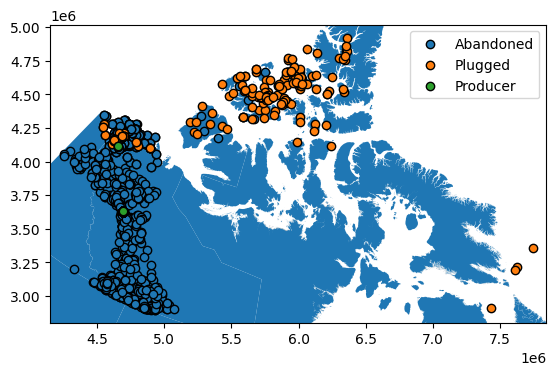

In [ ]:
geom = []
for i,row in AllUWI.iterrows():
	geom.append(MultiPoint([(x,y) for x,y in zip(row['x'],row['y'])]))
sl = gpd.read_file(r'source_data\boundary\lpr_000b16a_e.shp').to_crs('EPSG:3347')
fig,ax=plt.subplots()
sl.plot(ax=ax)
gdf = gpd.GeoDataFrame(data=AllUWI,geometry=geom,crs='NAD1983').to_crs('EPSG:3347')
for s in ['Abandoned','Plugged','Producer']:
	gdf.loc[gdf['Status']==s].plot(label=s,ax=ax,edgecolor='k')
ax.legend()
tb = gdf.total_bounds
tol = 1e5
ax.set_xlim(tb[0]-tol,tb[2]+tol)
ax.set_ylim(tb[1]-tol,tb[3]+tol)